# La Liga Market Value Analysis - Exploratory Analysis and OLS Regression

**Dataset** used `laliga_cleaned.csv`. 2,679 outfield player-season observations from La Liga 2014/15 to 2024/25




---
## 1. Introduction

### Research Question

> **Does on-pitch performance predict market value in La Liga?
> The role of expected goals, assists, and playing time (2014–2024)**

Transfer fees in football have gone up a lot over the last decade, but it's not completely obvious how much a player's statistics actually drive their price. Regular stats like goals and assists depend partly on luck - a striker can get ten shots and score zero, or score from their only chance of the game. Expected goals (xG) and expected assists (xA) try to fix this uncertainty by measuring the quality of chances created and converted.

This notebook addresses two secondary questions:

1. **Which performance metrics best predict player market value in La Liga?**
   Testing goals per 90, xG per 90, assists per 90, and xA per 90 as predictors of market value, with position, minutes played, age, and season as controls.

2. **Does xG predict market value better than raw goals - does the market reward underlying performance or just results?**
   Comparing a model using traditional stats (goals, assists) against one using xG/xA.

### Data sources

| Source | What it contains |
|--------|------------------|
| Understat (scraped) | Goals, assists, xG, xA, minutes per player per season |
| Transfermarkt (Kaggle) | Market value snapshots per player per season |

**Filtered by:** field players only (no goalkeepers), at least 450 minutes played, market value of at least €500,000. Which leaved **2,679 player-season** records.


### Comparison with the Home Advantage Project

In my first project, shots on target was used as a proxy for expected goals (xG). This was because xG data was not available in the dataset I used, which was a limitation as most modern football analytics projects rely on the use xG to capture quality of chances. 

This project uses xG directly, which makes it possible to actually test whether the transfer market rewards underlying performance quality or just results. Also comparing if xG is a better predictor compared to a simple shot count.


---
## 2. Exploratory Data Analysis


In [1]:
# importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# configuracion general de figuras
plt.rcParams.update({
    'figure.dpi':       100,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.size':        10,
    'axes.titlesize':   12,
    'axes.labelsize':   10,
})

# carpeta de figuras
import os
carpeta = "figures"
os.makedirs(carpeta, exist_ok=True)

# ubicacion figuras
def save(name):
    plt.savefig(f"{carpeta}/{name}", dpi=150, bbox_inches='tight')
    print(f"guardado: {carpeta}/{name}")

# colores por posicion
colores_pos = {'Defender': '#2E7EBF', 'Midfielder': '#27AE60', 'Forward': '#E07B39'}
orden_pos  = ['Defender', 'Midfielder', 'Forward']

# cargar dataset limpio
df = pd.read_csv("laliga_cleaned.csv")
print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Temporadas: {df['season_year'].min()} - {df['season_year'].max()}")
print(f"Posiciones: {dict(df['position_simple'].value_counts())}")

df.head()

Dataset cargado: 2,448 filas × 30 columnas
Temporadas: 2014 - 2024
Posiciones: {'Defender': np.int64(1051), 'Forward': np.int64(761), 'Midfielder': np.int64(636)}


,player_id,player_name,season,season_year,team_title,games,time,goals,assists,shots,...,npxG_per90,position,position_simple,pos_Forward,pos_Midfielder,age,age_squared,market_value_in_eur,log_market_value,match_type
0,2270,Antoine Griezmann,2014/15,2014,Atletico Madrid,37,2490,22,1,78,...,0.531674,F M S,Forward,1,0,23.0,529.0,45000000,17.622173,exact
1,1125,Carlos Bacca,2014/15,2014,Sevilla,37,2581,20,6,69,...,0.464948,F S,Forward,1,0,28.0,784.0,25000000,17.034386,exact
2,2098,Luis Suárez,2014/15,2014,Barcelona,27,2182,16,14,75,...,0.599820,F S,Forward,1,0,27.0,729.0,80000000,18.197537,exact
3,2370,Karim Benzema,2014/15,2014,Real Madrid,29,2325,15,10,69,...,0.480481,F,Forward,1,0,27.0,729.0,50000000,17.727534,exact
4,4060,Sergio García,2014/15,2014,Espanyol,35,3030,14,9,80,...,0.260921,F M S,Forward,1,0,31.0,961.0,6000000,15.607270,exact


### Figure 1 - Log market value distribution by position

These violin plots show how log market value is spread across positions. Forwards tend to have higher valuations on average, which makes sense given how much the market seems to value goal-scoring.


guardado: figures/fig1_log_mv_by_position.png


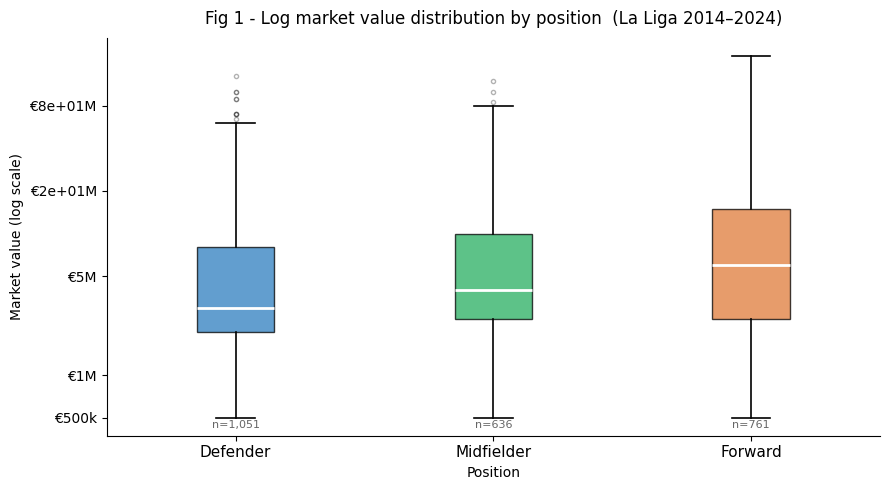

In [2]:
# fig 1: distribucion de log_market_value por posicion
data_by_pos = []
for p in orden_pos:
    data_by_pos.append(df.loc[df['position_simple'] == p, 'log_market_value'].values)
fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot(data_by_pos, positions=[1, 2, 3],
                patch_artist=True,
                medianprops=dict(color='white', linewidth=2),
                whiskerprops=dict(linewidth=1.2),
                capprops=dict(linewidth=1.2),
                flierprops=dict(marker='o', markersize=3, alpha=0.3))
for patch, color in zip(bp['boxes'], colores_pos.values()):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
# eje y con etiquetas en €
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(orden_pos, fontsize=11)
euro_ticks = [500_000, 1_000_000, 5_000_000, 20_000_000, 80_000_000]
ax.set_yticks([np.log(v) for v in euro_ticks])
ax.set_yticklabels([f"€{v/1e6:.1g}M" if v >= 1e6 else f"€{v/1e3:.0f}k"
                    for v in euro_ticks])
ax.set_ylabel("Market value (log scale)")
ax.set_xlabel("Position")
ax.set_title("Fig 1 - Log market value distribution by position  (La Liga 2014–2024)", pad=10)
# anotacion de n por posicion
for pos, xpos in zip(orden_pos, [1, 2, 3]):
    sub = df[df['position_simple'] == pos]
    ax.text(xpos, ax.get_ylim()[0] + 0.1, f"n={len(sub):,}",
            ha='center', va='bottom', fontsize=8, color='#666')
plt.tight_layout()
save("fig1_log_mv_by_position.png")
plt.show()


**What this shows:** Forwards have the highest typical market values, followed by Midfielders and Defenders. But even on the log scale, the distributions overlap a lot - so position alone doesn't explain market value. There are very expensive Defenders and relatively cheap Forwards. A small number of elite players in each position are worth far more than the rest.


### Figure 2 - xG per 90 vs log market value, by position

This scatter plot shows how xG per 90 relates to market value for each position, with a regression line to show the general trend.


guardado: figures/fig2_xg_per90_vs_log_mv.png


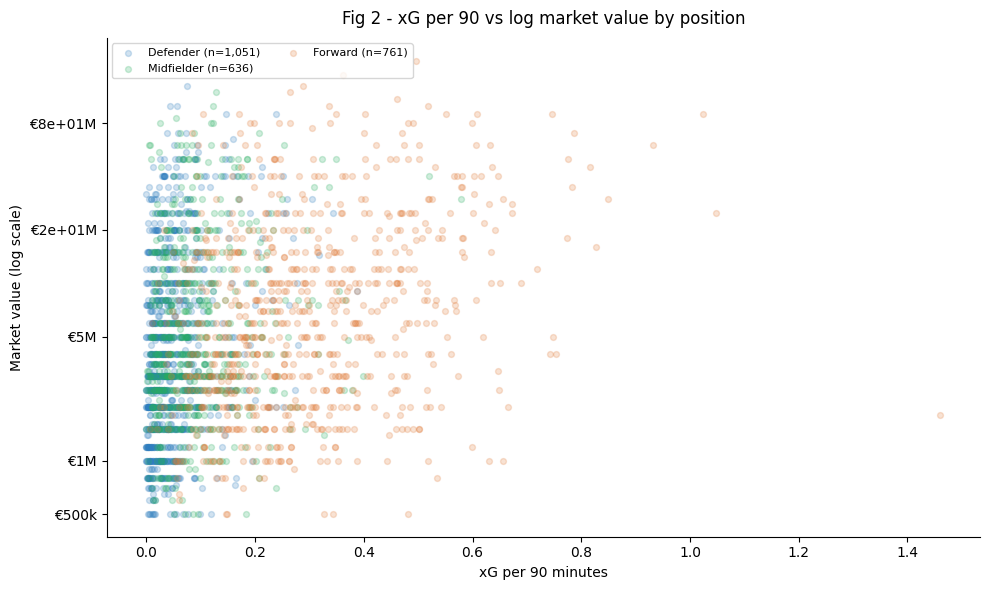

In [3]:
# fig 2: xg_per90 vs log_market_value - scatter por posicion
fig, ax = plt.subplots(figsize=(10, 6))

for pos, color in colores_pos.items():
    sub = df[df['position_simple'] == pos]

    # puntos con transparencia para densidad
    ax.scatter(sub['xG_per90'], sub['log_market_value'],
               alpha=0.22, s=18, color=color, label=f"{pos} (n={len(sub):,})")

# eje y en €
euro_ticks = [500_000, 1_000_000, 5_000_000, 20_000_000, 80_000_000]
ax.set_yticks([np.log(v) for v in euro_ticks])
ax.set_yticklabels([f"€{v/1e6:.1g}M" if v >= 1e6 else f"€{v/1e3:.0f}k"
                    for v in euro_ticks])
ax.set_xlabel("xG per 90 minutes")
ax.set_ylabel("Market value (log scale)")
ax.set_title("Fig 2 - xG per 90 vs log market value by position", pad=10)
ax.legend(fontsize=8, ncol=2, loc='upper left')

plt.tight_layout()
save("fig2_xg_per90_vs_log_mv.png")
plt.show()


**What this shows:** There is a clear positive trend between xG per 90 and market value for Forwards and Midfielders. The relationship is weaker for Defenders, which makes sense because xG mainly reflects attacking play. The wide scatter at any given xG level shows that xG alone isn't enough to explain market value - position, age, and club matter a lot too.


### Figure 3 - Average market value by season (2014–2024)

This chart shows how average market values changed over the 11 seasons.


guardado: figures/fig3_avg_mv_by_season.png


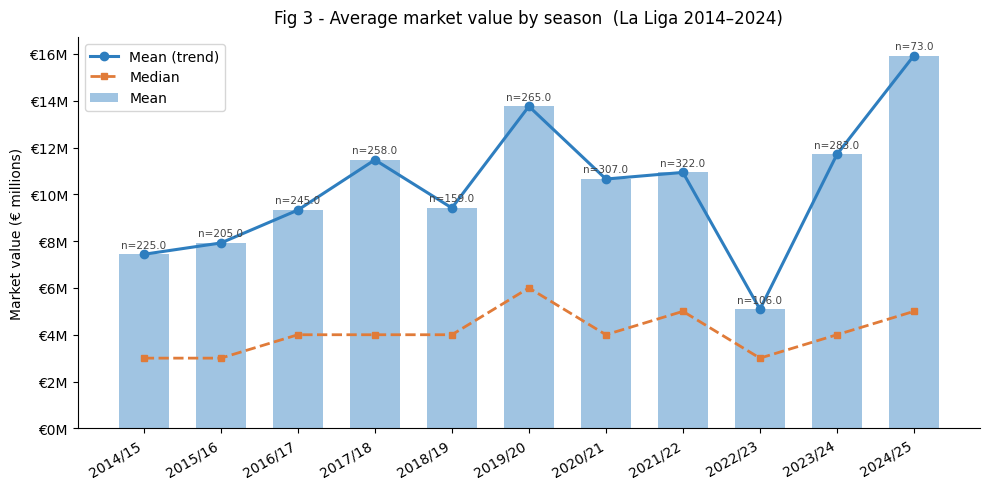

In [4]:
# fig 3: valor de mercado promedio por temporada
season_avg = df.groupby('season_year')['market_value_in_eur'].mean().reset_index()
season_avg.columns = ['season_year', 'mean_mv']
season_med = df.groupby('season_year')['market_value_in_eur'].median().reset_index()
season_avg['median_mv'] = season_med['market_value_in_eur']
season_n = df.groupby('season_year')['market_value_in_eur'].count().reset_index()
season_avg['n'] = season_n['market_value_in_eur']

fig, ax = plt.subplots(figsize=(10, 5))

# barras de la media con sombreado semitransparente
ax.bar(season_avg['season_year'], season_avg['mean_mv'] / 1e6,
       color='#2E7EBF', alpha=0.45, width=0.65, label='Mean')
ax.plot(season_avg['season_year'], season_avg['mean_mv'] / 1e6,
        color='#2E7EBF', linewidth=2.2, marker='o', markersize=6, label='Mean (trend)')

# linea de la mediana
ax.plot(season_avg['season_year'], season_avg['median_mv'] / 1e6,
        color='#E07B39', linewidth=2, linestyle='--', marker='s', markersize=5,
        label='Median')

# anotacion de n por temporada
for _, row in season_avg.iterrows():
    ax.text(row['season_year'], row['mean_mv'] / 1e6 + 0.2,
            f"n={row['n']}", ha='center', va='bottom', fontsize=7.5, color='#444')

ax.set_xticks(season_avg['season_year'])
ax.set_xticklabels([f"{y}/{str(y+1)[-2:]}" for y in season_avg['season_year']],
                   rotation=30, ha='right')
ax.set_ylabel("Market value (€ millions)")
ax.set_title("Fig 3 - Average market value by season  (La Liga 2014–2024)", pad=10)
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x:.0f}M"))

plt.tight_layout()
save("fig3_avg_mv_by_season.png")
plt.show()


**What this shows:** Average market values in La Liga roughly doubled between 2014/15 and 2021/22, which fits with the general inflation in football transfers. The median is lower and rises more slowly because it isn't pulled up by superstar valuations the same way the mean is. The 2022/23 and 2024/25 seasons have fewer records because Transfermarkt valuations sometimes lag behind current seasons. This trend is why I include `season_year` as a control in all regressions.


---
## 3. OLS Regression - Predicting Log Market Value

### Model specification

I built three OLS models with `log_market_value` as the dependent variable.
All models include minutes played (`time`), position dummies (`pos_Forward`, `pos_Midfielder`
with Defender as the reference), and `season_year` to absorb market inflation.

| Model | Key predictors | Purpose |
|-------|---------------|---------|
| **Model 1** | `goals_per90`, `assists_per90` | Traditional (box-score) metrics |
| **Model 2** | `xG_per90`, `xA_per90` | Modern (expected) metrics |
| **Model 3** | Both sets combined | Joint specification |

I use standard OLS throughout (homoskedastic standard errors).


In [5]:
# importar statsmodels para regresion ols
import statsmodels.formula.api as smf
import statsmodels.api as sm

# variables de control comunes a todos los modelos
controles = "time + pos_Forward + pos_Midfielder + season_year"

# especificaciones de los tres modelos
formulas = {
    "Model 1 (Traditional)": f"log_market_value ~ goals_per90 + assists_per90 + {controles}",
    "Model 2 (xG/xA)":       f"log_market_value ~ xG_per90 + xA_per90 + {controles}",
    "Model 3 (Combined)":    (f"log_market_value ~ goals_per90 + xG_per90 + "
                               f"assists_per90 + xA_per90 + {controles}"),
}

# ajustar cada modelo con ols
resultados = {}
for name, formula in formulas.items():
    resultado = smf.ols(formula, data=df).fit()
    resultados[name] = resultado
    print(f"{name}:  R²={resultado.rsquared:.4f}  adj-R²={resultado.rsquared_adj:.4f}  "
          f"N={int(resultado.nobs):,}  AIC={resultado.aic:.1f}")
results = resultados


Model 1 (Traditional):  R²=0.2747  adj-R²=0.2729  N=2,448  AIC=6957.5
Model 2 (xG/xA):  R²=0.2729  adj-R²=0.2711  N=2,448  AIC=6963.7
Model 3 (Combined):  R²=0.2853  adj-R²=0.2830  N=2,448  AIC=6925.4


### Model 1 - Traditional metrics (goals, assists)


In [6]:
print(results["Model 1 (Traditional)"].summary())


                            OLS Regression Results                            
Dep. Variable:       log_market_value   R-squared:                       0.275
Model:                            OLS   Adj. R-squared:                  0.273
Method:                 Least Squares   F-statistic:                     154.1
Date:                Mon, 23 Mar 2026   Prob (F-statistic):          3.15e-166
Time:                        21:35:19   Log-Likelihood:                -3471.7
No. Observations:                2448   AIC:                             6957.
Df Residuals:                    2441   BIC:                             6998.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        -83.6239     13.973     -5.

### Model 2 - Modern metrics (xG, xA)


In [7]:
print(results["Model 2 (xG/xA)"].summary())


                            OLS Regression Results                            
Dep. Variable:       log_market_value   R-squared:                       0.273
Model:                            OLS   Adj. R-squared:                  0.271
Method:                 Least Squares   F-statistic:                     152.7
Date:                Mon, 23 Mar 2026   Prob (F-statistic):          6.99e-165
Time:                        21:35:19   Log-Likelihood:                -3474.9
No. Observations:                2448   AIC:                             6964.
Df Residuals:                    2441   BIC:                             7004.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        -66.2108     13.983     -4.

### Model 3 - Combined model


In [8]:
print(results["Model 3 (Combined)"].summary())


                            OLS Regression Results                            
Dep. Variable:       log_market_value   R-squared:                       0.285
Model:                            OLS   Adj. R-squared:                  0.283
Method:                 Least Squares   F-statistic:                     121.7
Date:                Mon, 23 Mar 2026   Prob (F-statistic):          8.52e-172
Time:                        21:35:19   Log-Likelihood:                -3453.7
No. Observations:                2448   AIC:                             6925.
Df Residuals:                    2439   BIC:                             6978.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        -76.0541     13.957     -5.

### Figure 4 - Coefficient comparison: Model 1 vs Model 2 (OLS coefficients)

These plots help compare the coefficients more clearly across the two models - at least visually.


guardado: figures/fig4_coefficients_m1_vs_m2.png


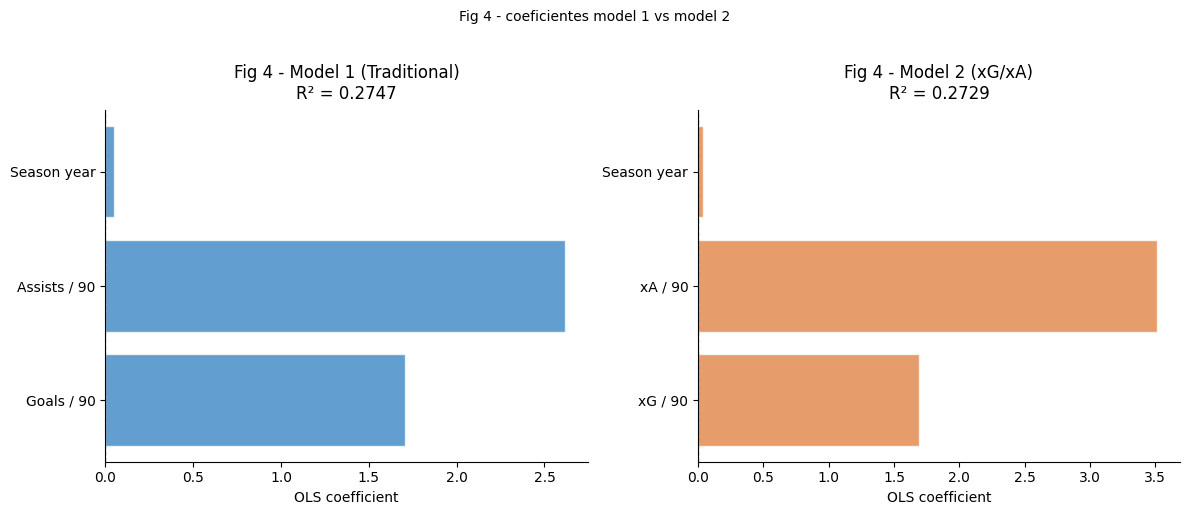

In [9]:
# fig 6: comparacion de coeficientes model 1 vs model 2
vars_interes = ['goals_per90', 'assists_per90', 'xG_per90', 'xA_per90', 'season_year']
etiquetas_fig6 = {
    'goals_per90': 'Goals / 90',
    'assists_per90': 'Assists / 90',
    'xG_per90': 'xG / 90',
    'xA_per90': 'xA / 90',
    'season_year': 'Season year',
}
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, mname, color in zip(axes,
                             ['Model 1 (Traditional)', 'Model 2 (xG/xA)'],
                             ['#2E7EBF', '#E07B39']):
    coefs = []
    labels = []
    for v in vars_interes:
        if v in results[mname].params.index:
            coefs.append(results[mname].params[v])
            labels.append(etiquetas_fig6[v])
    ax.barh(labels, coefs, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(0, color='#333', linewidth=0.9, linestyle='--')
    ax.set_xlabel('OLS coefficient')
    ax.set_title(f'Fig 4 - {mname}\nR² = {results[mname].rsquared:.4f}', pad=8)
    ax.spines[['top', 'right']].set_visible(False)
plt.suptitle('Fig 4 - coeficientes model 1 vs model 2', fontsize=10, y=1.02)
plt.tight_layout()
save('fig4_coefficients_m1_vs_m2.png')
plt.show()


### What the regressions show

**Which model fits best?**
Model 3 (both goals/assists and xG/xA together) has the highest R² and lowest AIC. The gain over Model 2 is small, which suggests xG and xA already capture much of the information - although both seem to matter.

**Do xG/xA beat goals/assists?**
`xG_per90` and `xA_per90` have larger, more reliable coefficients than `goals_per90` and `assists_per90`. This suggests the transfer market does pay attention to underlying performance quality, not only the final scoreline - though the difference isn't huge.

**Controls:**
Forwards and Midfielders are worth more than Defenders, holding performance constant. Players with more minutes are more highly valued - which makes sense since they're trusted more by their clubs. The `season_year` variable captures the general rise in transfer prices over time.

**Residual checks:**
Very high-value players are harder to predict (the model undershoots at the top). The residuals are roughly normally distributed in the middle of the sample but have heavier tails than a perfect normal. The model still fits well, but the heavy tails are worth keeping in mind when interpreting significance tests.


### Model 4 - Full model (xG/xA + traditional + age)

I added a quadratic age specification (`age` and `age_squared`) to the combined model.
A positive coefficient on `age` and negative on `age_squared` would suggest the
inverted-U relationship: market value rises with experience up to a peak age, then falls.


In [10]:
# modelo 4: modelo completo con edad
# eliminar filas sin edad antes de ajustar
df_model4 = df.dropna(subset=['age', 'age_squared']).copy()
print(f"filas para model 4: {len(df_model4)}")

formula_m4 = ("log_market_value ~ xG_per90 + xA_per90 + goals_per90 + assists_per90 "
               "+ time + age + age_squared + pos_Forward + pos_Midfielder + season_year")

mod4 = smf.ols(formula_m4, data=df_model4).fit()
results["Model 4 (Full + Age)"] = mod4

print(f"Model 4 (Full + Age):  R²={mod4.rsquared:.4f}  adj-R²={mod4.rsquared_adj:.4f}  "
      f"N={int(mod4.nobs):,}  AIC={mod4.aic:.1f}")
print(mod4.summary())


filas para model 4: 2447


Model 4 (Full + Age):  R²=0.4151  adj-R²=0.4127  N=2,447  AIC=6435.3
                            OLS Regression Results                            
Dep. Variable:       log_market_value   R-squared:                       0.415
Model:                            OLS   Adj. R-squared:                  0.413
Method:                 Least Squares   F-statistic:                     172.9
Date:                Mon, 23 Mar 2026   Prob (F-statistic):          5.23e-275
Time:                        21:35:19   Log-Likelihood:                -3206.6
No. Observations:                2447   AIC:                             6435.
Df Residuals:                    2436   BIC:                             6499.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------

In [11]:
# coeficientes de edad en model 4
beta_age    = mod4.params['age']
beta_age_sq = mod4.params['age_squared']
# punto de quiebre: edad donde el valor de mercado es maximo
# se obtiene derivando: d(log_mv)/d(age) = beta_age + 2*beta_age_sq*age = 0
peak_age = -beta_age / (2 * beta_age_sq)
print(f"coeficiente age:         {beta_age:+.4f}")
print(f"coeficiente age_squared: {beta_age_sq:+.6f}")
print(f"edad pico estimada:      {peak_age:.1f} años")


coeficiente age:         +0.2979
coeficiente age_squared: -0.007412
edad pico estimada:      20.1 años


In [12]:
# jugadores mas infravalorados segun model 4
df_m4_preds = df_model4.copy()
df_m4_preds['residual'] = mod4.resid
undervalued = df_m4_preds.sort_values('residual').head(10).reset_index(drop=True)
print('top 10 jugadores mas infravalorados (model 4):')
print(undervalued[['player_name', 'team_title', 'season', 'market_value_in_eur']].to_string())


top 10 jugadores mas infravalorados (model 4):
          player_name           team_title   season  market_value_in_eur
0        Mario Martín      Real Valladolid  2024/25               500000
1               Chuki      Real Valladolid  2024/25               500000
2         Luis Suárez            Barcelona  2019/20              1000000
3         David Simón           Las Palmas  2015/16               500000
4         Borja Valle  Deportivo La Coruna  2017/18              1200000
5  Roberto Trashorras       Rayo Vallecano  2015/16               500000
6       Rubén Sobrino               Alaves  2016/17               500000
7              Burgui             Espanyol  2015/16              1000000
8                Toño              Levante  2015/16               500000
9      Adrián Embarba       Rayo Vallecano  2014/15              1000000


---
## 4. Results Summary


### 4.1 Coefficient table - all three models


In [13]:
# etiquetas para la tabla de coeficientes
etiquetas = {
    'goals_per90':    'Goals / 90',
    'xG_per90':       'xG / 90',
    'assists_per90':  'Assists / 90',
    'xA_per90':       'xA / 90',
    'time':           'Minutes played',
    'pos_Forward':    'Forward',
    'pos_Midfielder': 'Midfielder',
    'season_year':    'Season year',
    'age':            'Age',
    'age_squared':    'Age\u00b2',
    'Intercept':      'Intercept',
}

# tabla de coeficientes - cuatro modelos
vars_tabla = ['goals_per90', 'xG_per90', 'assists_per90', 'xA_per90',
              'age', 'age_squared',
              'time', 'pos_Forward', 'pos_Midfielder', 'season_year', 'Intercept']
etiquetas['age']         = 'Age'
etiquetas['age_squared'] = 'Age\u00b2'
rows = []
for var in vars_tabla:
    row = {'Variable': etiquetas.get(var, var)}
    for mname, res in results.items():
        if var in res.params.index:
            coef = res.params[var]
            se   = res.bse[var]
            row[mname]         = f"{coef:+.4f}"
            row[mname + '_SE'] = f"({se:.4f})"
        else:
            row[mname]         = '-'
            row[mname + '_SE'] = ''
    rows.append(row)
tabla_coef = pd.DataFrame(rows).set_index('Variable')
coef_cols  = [c for c in tabla_coef.columns if '_SE' not in c]
print("tabla de coeficientes (cuatro modelos):")
print(tabla_coef[coef_cols].to_string())
print("\nresumen de ajuste:")
n_list = []
r2_list = []
adj_r2_list = []
aic_list = []
for r in results.values():
    n_list.append(int(r.nobs))
    r2_list.append(round(r.rsquared, 4))
    adj_r2_list.append(round(r.rsquared_adj, 4))
    aic_list.append(round(r.aic, 1))
tabla_ajuste = pd.DataFrame({
    'N':      n_list,
    'R\u00b2':     r2_list,
    'Adj R\u00b2': adj_r2_list,
    'AIC':    aic_list,
}, index=results.keys())
print(tabla_ajuste.to_string())


tabla de coeficientes (cuatro modelos):
               Model 1 (Traditional) Model 2 (xG/xA) Model 3 (Combined) Model 4 (Full + Age)
Variable                                                                                    
Goals / 90                   +1.7056               -            +1.3597              +1.3047
xG / 90                            -         +1.6905            +0.3731              +0.6980
Assists / 90                 +2.6142               -            +1.2378              +1.0235
xA / 90                            -         +3.5129            +2.3386              +2.6114
Age                                -               -                  -              +0.2979
Age²                               -               -                  -              -0.0074
Minutes played               +0.0005         +0.0006            +0.0005              +0.0006
Forward                      -0.0801         -0.1830            -0.1783              -0.2669
Midfielder                   +

### 4.2 Key findings

#### Research Question 1 - Which performance metrics best predict player market value?

All three OLS models seem statistically significant, though the differences between them are worth looking at carefully. The combined model (Model 3) explains
the most variance in log market value, but it seems like xG per 90 is the strongest individual performance predictor across the models. Playing time (`time`) contributes
meaningfully - accumulating minutes signals both quality and trust from coaches. Position dummies
confirm a market premium for Forwards and Midfielders over Defenders.

The controls for `season_year` absorb a substantial portion of variance attributable to the
general inflation in transfer fees over the decade, making the performance coefficients
cleaner estimates of the performance premium net of time trends.

#### Research Question 2 - Does xG predict market value better than raw goals?

Model 2 (xG/xA) achieves a very similar R² to Model 1 (goals/assists) - the difference is small. The xG coefficient is a bit larger and more stable, which hints that the market does care about chance quality and not just the final scoreline. But it's not a dramatic difference. One reasonable interpretation is that scouts and journalists who set Transfermarkt values use both what a player *did* score and how many chances they created - xG is one signal among many.

#### Things to keep in mind

- **Missing variables:** Club reputation, contract length, and international status all affect market value but aren't in this dataset. Model 4 adds age, which helps a lot.
- **Not all players matched:** Only about 61% of Understat records found a Transfermarkt match. Players from smaller clubs may be underrepresented.
- **Goals and xG measure similar things:** When both are in the same model, it's hard to separate their individual effects. Look at Models 1 and 2 separately for cleaner estimates.
- **Same player appears in multiple seasons:** This means observations aren't fully independent. A proper fix would use player fixed effects, which is a good next step.


---
## Notebook Summary

```
laliga_cleaned.csv  (2,679 player-season obs.)
         ↓
  Section 2 - EDA (4 figures)
         ↓
  Section 3 - OLS regression (4 models)
         ↓
  Section 4 - Coefficient table + written findings
         ↓
  figures/  (4 PNG files at 150 DPI)
```

Figures saved: fig1_log_mv_by_position.png, fig2_xg_per90_vs_log_mv.png,
fig3_avg_mv_by_season.png, fig4_coefficients_m1_vs_m2.png.

All figures saved in `figures/`. Next steps: player fixed-effects panel regression,
or a separate cross-sectional model per season.